# The Maximal Covering Location Problem

## Learning Objectives

After reading this chapter, you should be able to:

1. Explain what the Maximal Covering Location Problem, MCLP（最大覆盖选址问题） is and why it is useful in spatial optimization（空间优化）.
2. Distinguish MCLP from the p-Median Problem（p-中位数问题） introduced in Chapter 1.
3. Define coverage threshold（覆盖阈值）, covered demand（被覆盖需求）, and uncovered demand（未覆盖需求）.
4. Formulate MCLP using decision variables（决策变量）, an objective function（目标函数）, and constraints（约束条件）.
5. Solve a small MCLP example manually using a coverage matrix（覆盖矩阵）.
6. Implement MCLP in Python using brute-force search.
7. Interpret selected facilities, covered population, uncovered demand, and sensitivity to service thresholds.
8. Identify key limitations（局限性） of MCLP and explain how they motivate later extensions.

---

## Why This Topic Matters

In Chapter 1, we studied the p-Median Problem. Its central goal was to minimize total weighted travel distance. That is useful when we care about overall efficiency.

But many public service problems are not only about reducing average distance. Sometimes, planners care about whether people are served within a required standard.

For example:

- Can residents reach a clinic within 10 minutes?
- Can an ambulance reach most calls within 8 minutes?
- Can households access an emergency shelter within 5 miles?
- Can electric vehicle drivers find a charging station within 15 minutes?
- Can a city cover the maximum population with only a few public facilities?

These questions are not directly asking for the lowest average distance. Instead, they ask:

> How much demand can be covered within an acceptable distance or travel-time threshold?

This is the core idea of the Maximal Covering Location Problem, or MCLP.

MCLP is especially useful when a planning agency has a service standard（服务标准）. For example, a health department might say:

> A neighborhood is considered served if it is within 10 minutes of a clinic.

Under this view, a facility either covers a demand point or does not cover it. The goal is to choose $p$ facilities that cover as much weighted demand as possible.

---

## Big Picture Intuition

The p-Median Problem is about average efficiency.

MCLP is about service coverage.

The difference is subtle but important.

In p-Median, every demand point contributes to the objective through its distance to the nearest selected facility. A point that is 2 miles away is better than a point that is 6 miles away.

In MCLP, we first define a coverage threshold. For example:

$$
S = 5 \text{ miles}
$$

Then each demand point is classified as:

- covered, if it is within 5 miles of at least one selected facility;
- uncovered, if it is farther than 5 miles from every selected facility.

MCLP does not care whether a covered point is 1 mile away or 4.9 miles away. Both are simply covered.

This creates a different planning logic:

> MCLP chooses facilities to maximize the amount of demand that falls within the service standard.

---

### From p-Median to MCLP

| Chapter | Model | Main Question | Planning Value |
|---|---|---|---|
| Chapter 1 | p-Median | How do we minimize total weighted travel distance? | Efficiency |
| Chapter 2 | MCLP | How do we maximize demand covered within a threshold? | Service coverage |

This chapter builds directly on Chapter 1. We still use demand points, candidate sites, weights, and distances.

The major difference is that MCLP transforms distances into coverage relationships.

---

### A Simple Workflow

```mermaid
flowchart LR
    A[Demand points] --> C[Distance matrix]
    B[Candidate sites] --> C
    C --> D[Apply threshold]
    D --> E[Coverage matrix]
    E --> F[MCLP model]
    F --> G[Max covered demand]
```

This workflow shows the core mechanism. We first compute distances, just like in p-Median. Then we apply a service threshold. This converts the distance matrix into a coverage matrix. The optimization model then selects $p$ facilities that maximize covered weighted demand.

---

## Formal Definition and Core Equations

## Notation

| Symbol | Meaning |
|---|---|
| $i \in I$ | demand point index（需求点索引） |
| $j \in J$ | candidate site index（候选位置索引） |
| $w_i$ | weight of demand point $i$, such as population |
| $d_{ij}$ | distance or travel cost from demand point $i$ to candidate site $j$ |
| $S$ | coverage threshold（覆盖阈值） |
| $p$ | number of facilities to locate |
| $a_{ij}$ | coverage indicator: whether site $j$ can cover demand point $i$ |
| $x_j$ | binary variable: whether candidate site $j$ is selected |
| $z_i$ | binary variable: whether demand point $i$ is covered |

---

## Coverage Indicator

The key new idea in MCLP is the coverage indicator（覆盖指示变量）:

$$
a_{ij} =
\begin{cases}
1, & \text{if } d_{ij} \le S \\
0, & \text{if } d_{ij} > S
\end{cases}
$$

This means candidate site $j$ can cover demand point $i$ if the distance or travel time between them is no greater than the threshold $S$.

For example, if $S = 10$ minutes, then $a_{ij} = 1$ means site $j$ can serve demand point $i$ within 10 minutes.

---

## Decision Variables

The facility selection variable is:

$$
x_j =
\begin{cases}
1, & \text{if candidate site } j \text{ is selected} \\
0, & \text{otherwise}
\end{cases}
$$

The demand coverage variable is:

$$
z_i =
\begin{cases}
1, & \text{if demand point } i \text{ is covered by at least one selected facility} \\
0, & \text{otherwise}
\end{cases}
$$

Unlike p-Median, MCLP does not need to assign every demand point to exactly one facility. It only needs to know whether each demand point is covered.

---

## Objective Function

The MCLP objective is:

$$
\max \sum_{i \in I} w_i z_i
$$

This objective function maximizes total covered weighted demand.

If $w_i$ is population, then MCLP maximizes the number of people covered within the service threshold.

---

## Constraints

The first constraint says that exactly $p$ facilities can be selected:

$$
\sum_{j \in J} x_j = p
$$

The second constraint links coverage to selected facilities:

$$
z_i \le \sum_{j \in J} a_{ij} x_j,
\quad \forall i \in I
$$

This means demand point $i$ can be considered covered only if at least one selected facility can cover it.

If no selected facility is within the threshold, then:

$$
\sum_{j \in J} a_{ij} x_j = 0
$$

so $z_i$ must be 0.

Finally, the variables are binary:

$$
x_j \in \{0,1\},
\quad
z_i \in \{0,1\}
$$

Together, these equations define a binary integer programming（整数规划） model.

---

## How the Algorithm Works Step by Step

For a small MCLP problem, we can solve it by testing all possible combinations of $p$ candidate sites. For each combination, we check which demand points are covered and compute the total covered weight.

The conceptual steps are:

1. Prepare demand points and weights.
2. Prepare candidate facility sites.
3. Compute the distance matrix.
4. Choose a coverage threshold $S$.
5. Convert distances into a coverage matrix.
6. Choose $p$, the number of facilities.
7. Test each possible set of $p$ candidate sites.
8. Compute total covered demand for each set.
9. Select the set with the largest covered demand.
10. Interpret covered and uncovered demand.

---

## Algorithmic Workflow

```mermaid
flowchart TD
    A[Choose p and threshold S] --> B[Compute distances]
    B --> C[Build coverage matrix]
    C --> D[Test candidate sets]
    D --> E[Mark covered demand]
    E --> F[Sum covered weights]
    F --> G[Keep best solution]
    G --> H[Inspect uncovered demand]
```

This workflow highlights the main difference from p-Median. In p-Median, distances remain continuous costs. In MCLP, distances are converted into a binary covered/not-covered relationship.

---

## Core Mechanisms and Concepts

## Coverage Threshold

The coverage threshold $S$ is the most important parameter（参数） in MCLP.

It defines what “served” means.

Examples include:

- 5 miles from a clinic;
- 10 minutes from a fire station;
- 15 minutes from an emergency shelter;
- 500 meters from a bus stop;
- 30 minutes from a hospital.

Once $S$ is chosen, every demand-site pair becomes either covered or not covered.

This makes MCLP easy to interpret, but also sensitive to the threshold.

---

## Coverage Matrix

The coverage matrix（覆盖矩阵） is a binary matrix:

| Demand point | Site 1 | Site 2 | Site 3 |
|---|---|---|---|
| A | 1 | 0 | 0 |
| B | 1 | 1 | 0 |
| C | 0 | 1 | 1 |
| D | 0 | 0 | 1 |

A value of 1 means the site can cover the demand point. A value of 0 means it cannot.

The MCLP model is built on this matrix.

---

## Covered Demand

A demand point is covered if at least one selected facility can cover it.

If selected facilities are $S_p$, demand point $i$ is covered when:

$$
\sum_{j \in S_p} a_{ij} \ge 1
$$

If multiple selected facilities can cover the same demand point, it is still counted once.

This is important. MCLP maximizes covered demand, not repeated coverage.

---

## Uncovered Demand

Uncovered demand is demand that lies outside the threshold of all selected facilities.

Uncovered demand is not necessarily ignored in the real world, but in the basic MCLP objective, it contributes nothing.

This is both useful and dangerous.

It is useful because MCLP directly measures service-standard coverage. It is dangerous because demand just outside the threshold may be treated the same as demand extremely far away.

---

## Binary View of Distance

MCLP transforms distance into a binary condition:

$$
d_{ij} \le S
$$

or

$$
d_{ij} > S
$$

This is why MCLP is often easier to communicate to decision-makers. A planner can say:

> This solution covers 87% of the population within 10 minutes.

However, the binary cutoff also creates a strong limitation. A demand point 10.1 minutes away is considered uncovered, even though it is almost within the standard.

---

## Assumptions, Strengths, Limitations, and Trade-offs

## Assumptions

The standard MCLP assumes:

1. Demand points and candidate sites are known.
2. Demand weights are fixed.
3. A single coverage threshold $S$ is defined.
4. A demand point is covered if it is within $S$ of at least one selected facility.
5. Facilities have unlimited capacity.
6. All selected facilities are equally able to serve covered demand.
7. Demand is counted once, even if multiple selected facilities cover it.
8. The objective is to maximize covered weighted demand.

These assumptions make the model clear and policy-friendly, but they also create limitations.

---

## Strengths

MCLP is useful because it aligns directly with service standards.

If a city has a goal such as “maximize population within a 10-minute drive of a clinic,” MCLP is more natural than p-Median.

Its results are also easy to communicate:

> With three facilities, we can cover 82% of the population within 10 minutes.

This is often more understandable to non-technical stakeholders than total weighted travel distance.

---

## Limitations

### Limitation 1: MCLP is highly sensitive to the coverage threshold

Changing $S$ from 5 miles to 6 miles can change the coverage matrix and therefore the selected facilities.

#### Why this happens:

The threshold converts continuous distance into a binary decision.

#### Possible improvement:

Conduct sensitivity analysis using multiple thresholds, or use gradual coverage models where coverage decays with distance.

---

### Limitation 2: MCLP treats all covered demand equally

A point 1 mile away and a point 4.9 miles away are both covered if $S = 5$.

#### Why this matters:

The model ignores differences inside the service area.

#### Possible improvement:

Use distance-decay coverage, probabilistic coverage, or hybrid models that combine coverage and travel cost.

---

### Limitation 3: MCLP treats all uncovered demand equally

A point 5.1 miles away and a point 50 miles away are both uncovered.

#### Why this matters:

The model does not distinguish near misses from severe access gaps.

#### Possible improvement:

Report distance-to-nearest-facility for uncovered demand or use a multi-objective model that also penalizes distance.

---

### Limitation 4: MCLP may create redundant coverage

Because the basic objective counts each covered demand point only once, it does not value backup coverage unless explicitly modeled.

#### Why this matters:

In emergency planning, being covered by two facilities may be better than being covered by one.

#### Possible improvement:

Use backup coverage models or multi-coverage location models.

---

### Limitation 5: MCLP assumes unlimited facility capacity

A facility may cover a large population, but the model does not check whether it can actually serve them.

#### Why this matters:

Clinics, shelters, hospitals, and schools have capacity constraints.

#### Possible improvement:

Use capacitated MCLP or add facility capacity constraints.

---

### Limitation 6: MCLP depends on the distance metric

Like p-Median, MCLP can be misleading if Euclidean distance is used when network travel time is more appropriate.

#### Possible improvement:

Use road-network travel times, transit time, walking accessibility, or cost-distance surfaces.

---

## Worked Toy Example

Suppose a city has four demand points and three candidate sites. The city can select $p = 1$ facility. A demand point is covered if it is within $S = 5$ distance units.

The demand weights are:

| Demand point | Weight |
|---|---|
| A | 10 |
| B | 20 |
| C | 5 |
| D | 15 |

The distance matrix is:

| Demand point | Site 1 | Site 2 | Site 3 |
|---|---|---|---|
| A | 2 | 6 | 9 |
| B | 4 | 3 | 7 |
| C | 8 | 5 | 2 |
| D | 7 | 4 | 3 |

Because $S = 5$, we convert the distance matrix into a coverage matrix.

| Demand point | Site 1 | Site 2 | Site 3 |
|---|---|---|---|
| A | 1 | 0 | 0 |
| B | 1 | 1 | 0 |
| C | 0 | 1 | 1 |
| D | 0 | 1 | 1 |

Now we evaluate each candidate site.

## If we choose Site 1

Site 1 covers A and B.

$$
10 + 20 = 30
$$

Covered demand = 30.

---

### If we choose Site 2

Site 2 covers B, C, and D.

$$
20 + 5 + 15 = 40
$$

Covered demand = 40.

---

### If we choose Site 3

Site 3 covers C and D.

$$
5 + 15 = 20
$$

Covered demand = 20.

---

The best choice is Site 2 because it covers the largest total demand:

$$
40
$$

Notice that this is the same site selected in the p-Median toy example from Chapter 1. However, the reason is different.

In p-Median, Site 2 was best because it minimized total weighted distance.  
In MCLP, Site 2 is best because it covers the largest weighted demand within the threshold.

This distinction is central.

---

## Computational Lab: Solving MCLP in Python

### Lab Problem

We will use the same synthetic city structure as the p-Median chapter: several neighborhoods and candidate clinic sites. But now the planning question changes.

Instead of asking:

> Which two clinics minimize total weighted travel distance?

we ask:

> Which two clinics cover the most population within a given service threshold?

In this lab, we will:

1. create demand points and candidate sites;
2. compute a distance matrix;
3. convert the distance matrix into a coverage matrix;
4. solve MCLP using brute-force search;
5. visualize selected facilities and covered demand;
6. test different coverage thresholds;
7. compare MCLP’s logic with p-Median;
8. discuss limitations and improvement pathways.

---

## Create the Toy Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

np.random.seed(42)

# Demand points: x, y coordinates and population weights
demand = pd.DataFrame({
    "name": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "x": [1, 2, 2, 4, 6, 7, 8, 9],
    "y": [8, 7, 5, 6, 3, 4, 2, 1],
    "weight": [80, 120, 60, 100, 90, 70, 50, 40]
})

# Candidate facility sites
candidates = pd.DataFrame({
    "site": ["S1", "S2", "S3", "S4", "S5"],
    "x": [1, 3, 5, 7, 9],
    "y": [7, 5, 4, 3, 2]
})

demand, candidates

(  name  x  y  weight
 0    A  1  8      80
 1    B  2  7     120
 2    C  2  5      60
 3    D  4  6     100
 4    E  6  3      90
 5    F  7  4      70
 6    G  8  2      50
 7    H  9  1      40,
   site  x  y
 0   S1  1  7
 1   S2  3  5
 2   S3  5  4
 3   S4  7  3
 4   S5  9  2)

This is the same type of data used for p-Median. Reusing the same dataset is useful because it allows us to see how changing the objective function changes the spatial decision.

---

## Visualize Demand Points and Candidate Sites

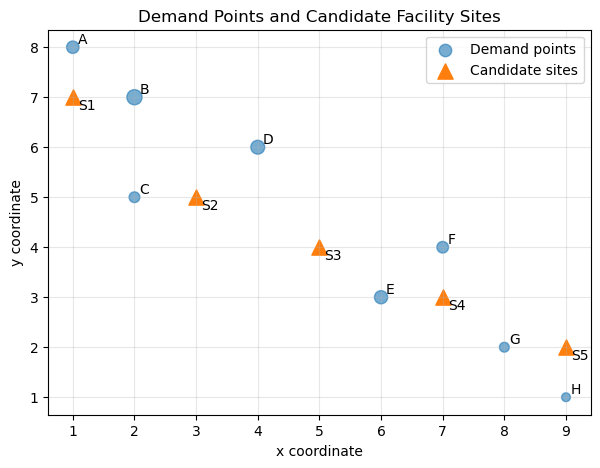

In [2]:
plt.figure(figsize=(7, 5))

plt.scatter(
    demand["x"], demand["y"],
    s=demand["weight"],
    alpha=0.6,
    label="Demand points"
)

plt.scatter(
    candidates["x"], candidates["y"],
    marker="^",
    s=120,
    label="Candidate sites"
)

for _, row in demand.iterrows():
    plt.text(row["x"] + 0.08, row["y"] + 0.08, row["name"])

for _, row in candidates.iterrows():
    plt.text(row["x"] + 0.08, row["y"] - 0.25, row["site"])

plt.title("Demand Points and Candidate Facility Sites")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The circle size represents demand weight. Larger circles indicate neighborhoods with more population. The triangles are candidate facility sites.

Before building an optimization model, we should always inspect the spatial layout. This helps us understand whether the final solution is reasonable.

---

## Compute the Distance Matrix

In [3]:
def euclidean_distance_matrix(demand_df, candidate_df):
    distances = np.zeros((len(demand_df), len(candidate_df)))
    
    for i, drow in demand_df.iterrows():
        for j, crow in candidate_df.iterrows():
            dx = drow["x"] - crow["x"]
            dy = drow["y"] - crow["y"]
            distances[i, j] = np.sqrt(dx**2 + dy**2)
    
    return distances

D = euclidean_distance_matrix(demand, candidates)

distance_df = pd.DataFrame(
    D,
    index=demand["name"],
    columns=candidates["site"]
)

distance_df.round(2)

site,S1,S2,S3,S4,S5
name,,,,,
A,1.00,3.61,5.66,7.81,10.00
B,1.00,2.24,4.24,6.40,8.60
C,2.24,1.00,3.16,5.39,7.62
D,3.16,1.41,2.24,4.24,6.40
E,6.40,3.61,1.41,1.00,3.16
F,6.71,4.12,2.00,1.00,2.83
G,8.60,5.83,3.61,1.41,1.00
H,10.00,7.21,5.00,2.83,1.00


This distance matrix is the same type of input used by p-Median. The difference is what we do next.

In p-Median, we used distances directly in the objective function.

In MCLP, we convert distances into coverage indicators.

---

## Convert Distance into Coverage

Let the coverage threshold be:

$$
S = 2.5
$$

A demand point is covered by a candidate site if its distance is less than or equal to 2.5.

In [4]:
S = 2.5

coverage_matrix = (D <= S).astype(int)

coverage_df = pd.DataFrame(
    coverage_matrix,
    index=demand["name"],
    columns=candidates["site"]
)

coverage_df

site,S1,S2,S3,S4,S5
name,,,,,
A,1,0,0,0,0
B,1,1,0,0,0
C,1,1,0,0,0
D,0,1,1,0,0
E,0,0,1,1,0
F,0,0,1,1,0
G,0,0,0,1,1
H,0,0,0,0,1


This table is the coverage matrix.

A value of 1 means the candidate site can cover the demand point. A value of 0 means it cannot.

This is the key MCLP transformation:

$$
\text{distance matrix} \rightarrow \text{coverage matrix}
$$

---

## Define the MCLP Objective

For a selected set of facilities, a demand point is covered if at least one selected facility can cover it.

In [5]:
def evaluate_mclp_solution(selected_sites, coverage_matrix, weights):
    """
    Compute total covered demand for a selected set of candidate sites.
    
    selected_sites: tuple of candidate site indices
    coverage_matrix: binary array with shape 
                     (number of demand points, number of candidate sites)
    weights: array of demand weights
    """
    selected_coverage = coverage_matrix[:, selected_sites]
    
    # A demand point is covered if at least one selected site covers it
    is_covered = selected_coverage.max(axis=1)
    
    total_covered_weight = np.sum(weights * is_covered)
    
    return total_covered_weight, is_covered

This function implements the MCLP objective.

Unlike p-Median, we are not summing weighted distances. We are summing weights only for demand points that are covered.

---

## Brute-Force Solver for MCLP

In [6]:
def solve_mclp_bruteforce(coverage_matrix, weights, p):
    n_candidates = coverage_matrix.shape[1]
    
    best_solution = None
    best_covered_weight = -np.inf
    best_covered_status = None
    
    for selected_sites in combinations(range(n_candidates), p):
        covered_weight, covered_status = evaluate_mclp_solution(
            selected_sites,
            coverage_matrix,
            weights
        )
        
        if covered_weight > best_covered_weight:
            best_covered_weight = covered_weight
            best_solution = selected_sites
            best_covered_status = covered_status
    
    return {
        "selected_sites": best_solution,
        "covered_weight": best_covered_weight,
        "covered_status": best_covered_status
    }

weights = demand["weight"].values

result_mclp = solve_mclp_bruteforce(
    coverage_matrix,
    weights,
    p=2
)

selected_site_names = candidates.iloc[list(result_mclp["selected_sites"])]["site"].tolist()

selected_site_names, result_mclp["covered_weight"]

(['S1', 'S3'], 520)

This brute-force solver tests every pair of candidate sites and keeps the pair that covers the largest weighted demand.

This is transparent and useful for learning. But for large real-world problems, we would usually use an integer programming solver.

---

## Inspect Covered and Uncovered Demand

In [7]:
coverage_result = demand.copy()
coverage_result["covered"] = result_mclp["covered_status"].astype(bool)
coverage_result["covered_weight"] = coverage_result["weight"] * coverage_result["covered"]

coverage_result

,name,x,y,weight,covered,covered_weight
0,A,1,8,80,True,80
1,B,2,7,120,True,120
2,C,2,5,60,True,60
3,D,4,6,100,True,100
4,E,6,3,90,True,90
5,F,7,4,70,True,70
6,G,8,2,50,False,0
7,H,9,1,40,False,0


This table tells us which demand points are covered by the selected facilities.

The total covered population is:

In [8]:
coverage_result["covered_weight"].sum()

520

The total demand is:

In [9]:
coverage_result["weight"].sum()

610

The coverage percentage is:

In [10]:
coverage_percentage = (
    coverage_result["covered_weight"].sum() / coverage_result["weight"].sum()
)

coverage_percentage

0.8524590163934426

This percentage is one of the most useful outputs of MCLP. It tells us what share of the total weighted demand is covered by the selected facilities.

---

## Visualize the MCLP Solution

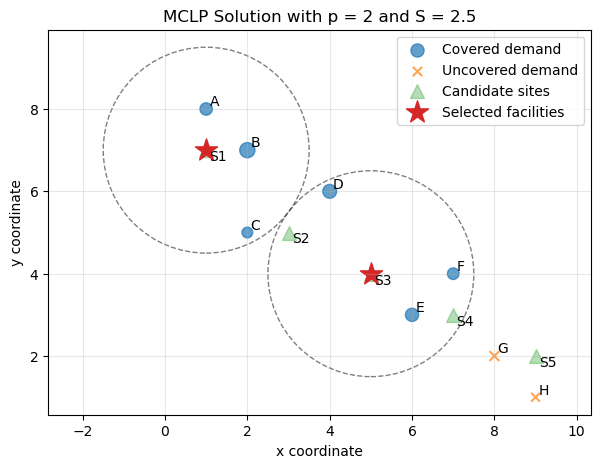

In [11]:
def plot_mclp_solution(demand_df, candidate_df, result, threshold, title):
    selected_indices = list(result["selected_sites"])
    covered_status = result["covered_status"].astype(bool)
    
    plt.figure(figsize=(7, 5))
    
    # Covered and uncovered demand points
    covered = demand_df[covered_status]
    uncovered = demand_df[~covered_status]
    
    plt.scatter(
        covered["x"], covered["y"],
        s=covered["weight"],
        alpha=0.7,
        label="Covered demand"
    )
    
    plt.scatter(
        uncovered["x"], uncovered["y"],
        s=uncovered["weight"],
        alpha=0.7,
        marker="x",
        label="Uncovered demand"
    )
    
    # All candidate sites
    plt.scatter(
        candidate_df["x"], candidate_df["y"],
        marker="^",
        s=100,
        alpha=0.35,
        label="Candidate sites"
    )
    
    # Selected sites
    selected = candidate_df.iloc[selected_indices]
    plt.scatter(
        selected["x"], selected["y"],
        marker="*",
        s=280,
        label="Selected facilities"
    )
    
    # Draw coverage circles
    ax = plt.gca()
    for _, row in selected.iterrows():
        circle = plt.Circle(
            (row["x"], row["y"]),
            threshold,
            fill=False,
            linestyle="--",
            alpha=0.5
        )
        ax.add_patch(circle)
    
    # Labels
    for _, row in demand_df.iterrows():
        plt.text(row["x"] + 0.08, row["y"] + 0.08, row["name"])
    
    for _, row in candidate_df.iterrows():
        plt.text(row["x"] + 0.08, row["y"] - 0.25, row["site"])
    
    plt.title(title)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    plt.axis("equal")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_mclp_solution(
    demand,
    candidates,
    result_mclp,
    threshold=S,
    title=f"MCLP Solution with p = 2 and S = {S}"
)

This figure shows the logic of MCLP visually.

The dashed circles represent service coverage areas. Demand points inside at least one selected service area are covered. Demand points outside all selected service areas are uncovered.

This is different from p-Median. In p-Median, every demand point is assigned to a facility. In MCLP, some demand points may remain uncovered.

---

## Sensitivity to the Coverage Threshold

MCLP is highly sensitive to the threshold $S$. Let us test several thresholds.

In [12]:
thresholds = [1.5, 2.0, 2.5, 3.0, 3.5]

threshold_summary = []

for S_test in thresholds:
    coverage_matrix_test = (D <= S_test).astype(int)
    
    result = solve_mclp_bruteforce(
        coverage_matrix_test,
        weights,
        p=2
    )
    
    selected_names = candidates.iloc[list(result["selected_sites"])]["site"].tolist()
    coverage_pct = result["covered_weight"] / weights.sum()
    
    threshold_summary.append({
        "threshold": S_test,
        "selected_sites": selected_names,
        "covered_weight": result["covered_weight"],
        "coverage_percentage": coverage_pct
    })

threshold_summary_df = pd.DataFrame(threshold_summary)
threshold_summary_df

,threshold,selected_sites,covered_weight,coverage_percentage
0,1.5,"[S1, S4]",410,0.672131
1,2.0,"[S1, S4]",410,0.672131
2,2.5,"[S1, S3]",520,0.852459
3,3.0,"[S2, S4]",530,0.868852
4,3.5,"[S1, S4]",610,1.000000


This table shows how coverage changes as the service threshold changes.

Usually, a larger threshold increases coverage, but it may also change which sites are selected.

---

## Plot Coverage Percentage by Threshold

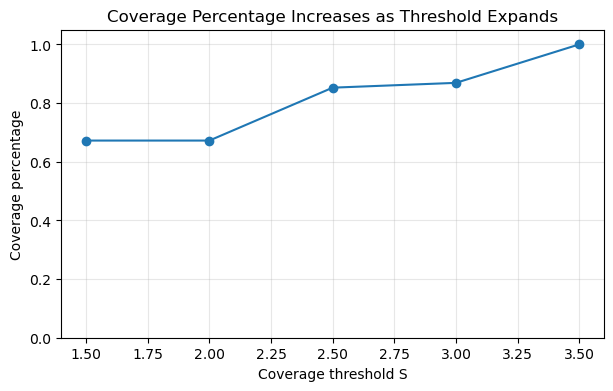

In [13]:
plt.figure(figsize=(7, 4))

plt.plot(
    threshold_summary_df["threshold"],
    threshold_summary_df["coverage_percentage"],
    marker="o"
)

plt.title("Coverage Percentage Increases as Threshold Expands")
plt.xlabel("Coverage threshold S")
plt.ylabel("Coverage percentage")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

This plot shows a key MCLP lesson:

> The selected solution is not independent of the service threshold.

If the threshold is too small, many demand points may be impossible to cover. If the threshold is too large, almost everything may be covered, and the model may become less informative.

A good MCLP study should therefore report sensitivity across several thresholds.

---

## Compare MCLP with p-Median on the Same Data

To connect with Chapter 1, let us implement the p-Median brute-force solver again and compare the two models.

In [14]:
def evaluate_p_median_solution(selected_sites, distance_matrix, weights):
    selected_distances = distance_matrix[:, selected_sites]
    nearest_distance = selected_distances.min(axis=1)
    assigned_site_position = selected_distances.argmin(axis=1)
    assigned_sites = np.array(selected_sites)[assigned_site_position]
    total_cost = np.sum(weights * nearest_distance)
    return total_cost, nearest_distance, assigned_sites


def solve_p_median_bruteforce(distance_matrix, weights, p):
    n_candidates = distance_matrix.shape[1]
    best_solution = None
    best_cost = np.inf
    best_assignment = None
    best_nearest_distance = None
    
    for selected_sites in combinations(range(n_candidates), p):
        total_cost, nearest_distance, assigned_sites = evaluate_p_median_solution(
            selected_sites,
            distance_matrix,
            weights
        )
        
        if total_cost < best_cost:
            best_cost = total_cost
            best_solution = selected_sites
            best_assignment = assigned_sites
            best_nearest_distance = nearest_distance
    
    return {
        "selected_sites": best_solution,
        "total_cost": best_cost,
        "assigned_sites": best_assignment,
        "nearest_distance": best_nearest_distance
    }


result_pmedian = solve_p_median_bruteforce(D, weights, p=2)

pmedian_sites = candidates.iloc[list(result_pmedian["selected_sites"])]["site"].tolist()
mclp_sites = candidates.iloc[list(result_mclp["selected_sites"])]["site"].tolist()

comparison = pd.DataFrame({
    "model": ["p-Median", "MCLP"],
    "selected_sites": [pmedian_sites, mclp_sites],
    "main_metric": [
        f"Total weighted distance = {result_pmedian['total_cost']:.2f}",
        f"Covered weight = {result_mclp['covered_weight']:.2f}"
    ]
})

comparison

,model,selected_sites,main_metric
0,p-Median,"[S1, S4]",Total weighted distance = 994.24
1,MCLP,"[S1, S3]",Covered weight = 520.00


This comparison is important. The two models may select the same sites or different sites. Even if they select the same sites, they are optimizing different goals.

p-Median asks:

> How do we reduce total weighted distance?

MCLP asks:

> How do we cover the most demand within the threshold?

The selected solution reflects the objective function.

---

## How to Interpret the Results

A good MCLP report should include more than just selected sites.

## Selected facilities

The selected facilities are the candidate sites that maximize covered weighted demand.

They are optimal only under the chosen threshold, demand weights, candidate sites, and distance metric.

---

### Covered demand

Covered demand is the total weight of demand points within the threshold of at least one selected facility.

If $w_i$ is population, this tells us how many people are served according to the standard.

---

### Coverage percentage

Coverage percentage is:

$$
\frac{\text{covered weighted demand}}{\text{total weighted demand}}
$$

This is often the most communicable result.

For example:

> The selected two clinics cover 78% of the population within 2.5 distance units.

---

### Uncovered demand

Uncovered demand deserves special attention.

A high coverage percentage may still hide underserved communities. For example, if 90% of the population is covered but the remaining 10% belongs to vulnerable or rural communities, the solution may not be acceptable.

---

### Threshold sensitivity

Because MCLP depends strongly on $S$, you should report results across multiple thresholds.

A solution that is stable across thresholds may be more robust. A solution that changes dramatically may require careful interpretation.

---

### What not to conclude

Do not conclude that uncovered demand has no service need.

Do not conclude that all covered demand has equal accessibility.

Do not conclude that the selected sites are best under every service standard.

MCLP gives a coverage-based answer under a specific definition of coverage.

---

## Limitations and Pathways for Improvement

MCLP is clear, practical, and policy-friendly, but its simplicity creates important limitations.

| Limitation | Why It Happens | Possible Improvement |
|---|---|---|
| Sensitive to threshold | Continuous distance is converted to binary coverage | Sensitivity analysis, gradual coverage |
| Covered points treated equally | Any point within $S$ is simply covered | Distance-decay functions |
| Uncovered points treated equally | Any point beyond $S$ is uncovered | Penalize distance beyond threshold |
| No capacity | Facilities can cover unlimited demand | Capacitated MCLP |
| No backup coverage | Demand covered by two facilities is not valued more | Backup coverage models |
| Single objective | Only maximizes coverage | Multi-objective optimization |
| Fixed demand | Demand is assumed static | Dynamic or stochastic models |
| Distance metric may be unrealistic | Euclidean distance may not reflect real travel | Network travel time |

The key limitation is the threshold effect.

A demand point just inside the threshold is fully covered. A demand point just outside the threshold is fully uncovered. This sharp boundary can be unrealistic.

This limitation motivates later models such as:

- gradual coverage location models;
- probabilistic coverage models;
- backup coverage models;
- capacitated covering models;
- equity-aware MCLP;
- multi-objective location models.

A strong way to understand MCLP is:

> MCLP is excellent for service-standard planning, but weak when access should be understood as gradual rather than binary.

---

## Common Pitfalls and Misunderstandings

## Pitfall 1: Choosing the threshold arbitrarily

The threshold $S$ should be justified. It may come from policy, professional standards, travel behavior, emergency response targets, or empirical evidence.

A threshold chosen without justification weakens the analysis.

---

## Pitfall 2: Reporting only covered percentage

A high coverage percentage is not enough. You should also report who remains uncovered and where they are located.

---

## Pitfall 3: Ignoring near misses

A demand point just outside the threshold may still have reasonable access. Basic MCLP treats it as fully uncovered.

This is why gradual coverage models may be useful.

---

## Pitfall 4: Using Euclidean distance without justification

Straight-line distance is often inappropriate for real accessibility analysis. Network travel time is usually better for roads, emergency services, clinics, and schools.

---

## Pitfall 5: Confusing coverage with capacity

A demand point can be covered by a facility even if the facility cannot realistically serve everyone assigned to it.

Coverage does not equal capacity.

---

## Pitfall 6: Assuming MCLP is more equitable than p-Median

MCLP can improve coverage, but it does not automatically guarantee equity. If high-density areas dominate the demand weight, low-density areas can still be left uncovered.

---

## Comparison with Related Methods

| Method | Main Goal | Key Question | Main Limitation | Main Trade-off |
|---|---|---|---|---|
| p-Median | Minimize total weighted distance | How do we reduce average travel cost? | May underserve remote areas | Efficient but may be inequitable |
| p-Center | Minimize maximum distance | How do we protect the worst-served demand point? | May sacrifice average efficiency | Equitable but less efficient |
| MCLP | Maximize covered demand within threshold | How many people are served within a standard? | Sensitive to threshold | Clear service standard but binary coverage |
| Gradual Coverage Model | Maximize distance-decayed coverage | How does coverage decline with distance? | Requires decay function | More realistic but less simple |
| Backup Coverage Model | Maximize primary and backup coverage | Who has redundant service? | More complex objective | Better for reliability planning |

This comparison shows why MCLP is a natural second chapter after p-Median. It changes the planning value from efficiency to coverage.

---

## Practical Advice

When using MCLP in real spatial analysis, report the following clearly:

1. **Study area:** What region is being analyzed?
2. **Demand representation:** Are demand points census centroids, buildings, grid cells, parcels, or events?
3. **Demand weights:** Are weights population, risk, calls, customers, or vulnerable groups?
4. **Candidate sites:** Where can facilities realistically be placed?
5. **Distance metric:** Is it Euclidean distance, network travel time, walking time, or cost distance?
6. **Coverage threshold:** What value of $S$ is used, and why?
7. **Number of facilities:** Why was $p$ chosen?
8. **Coverage matrix:** How was coverage defined?
9. **Solver or algorithm:** How was the model solved?
10. **Covered and uncovered demand:** Who is served and who is not?
11. **Sensitivity analysis:** How do results change under different thresholds?
12. **Limitations:** What does the model ignore?
13. **Policy interpretation:** What can and cannot be concluded?

A strong MCLP study should not simply say:

> These sites cover the most people.

It should say:

> These sites cover the most weighted demand within this threshold, under this distance metric, candidate site set, demand representation, and value of $p$.

That statement is more precise and more defensible.

---

## Summary

The Maximal Covering Location Problem is a classic spatial optimization model for service-standard planning. It chooses $p$ facilities to maximize the amount of demand covered within a specified threshold.

Its core idea is:

$$
\text{Choose facilities that cover the most weighted demand within } S.
$$

Compared with p-Median, MCLP shifts the focus from average travel cost to coverage within an acceptable service standard.

MCLP is powerful because it is easy to communicate and directly connected to policy targets. However, it is also limited because coverage is binary and highly sensitive to the chosen threshold.

A memorable way to remember MCLP is:

> p-Median asks how far people travel on average; MCLP asks how many people are close enough.

---

## Quiz

## Conceptual Questions

### Q1: What is the main goal of MCLP?

A. Minimize the maximum travel distance

B. Minimize total weighted travel distance

C. Maximize covered weighted demand within a threshold

D. Assign every demand point to exactly one facility

<details>
<summary>Answer</summary>

Correct answer: C.

MCLP maximizes the total demand covered within a specified service threshold.

</details>

---

### Q2: What does the coverage threshold $S$ define?

A. The number of facilities to select

B. The maximum distance or time for a demand point to be considered covered

C. The total population of the study area

D. The weight of each candidate site

<details>
<summary>Answer</summary>

Correct answer: B.

The threshold $S$ defines whether a demand point is covered by a facility.

</details>

---

### Q3: What does $a_{ij} = 1$ mean?

A. Demand point $i$ is assigned to site $j$

B. Site $j$ is selected

C. Site $j$ can cover demand point $i$ under the threshold

D. Demand point $i$ has weight 1

<details>
<summary>Answer</summary>

Correct answer: C.

The coverage indicator $a_{ij}$ equals 1 when $d_{ij} \leq S$.

</details>

---

### Q4: How is MCLP different from p-Median?

A. MCLP uses demand points, while p-Median does not

B. MCLP maximizes covered demand, while p-Median minimizes total weighted distance

C. MCLP does not require candidate sites

D. MCLP always produces a more equitable result

<details>
<summary>Answer</summary>

Correct answer: B.

MCLP focuses on coverage within a threshold. p-Median focuses on reducing total weighted travel distance.

</details>

---

### Q5: Why is MCLP sensitive to the threshold $S$?

A. Because $S$ changes demand weights directly

B. Because $S$ determines which demand-site pairs are considered covered

C. Because $S$ determines the number of candidate sites

D. Because $S$ removes the need for optimization

<details>
<summary>Answer</summary>

Correct answer: B.

Changing $S$ changes the coverage matrix, which can change the optimal solution.

</details>

---

## Applied Questions

### Q6: Suppose a demand point has weight 50. It is within the threshold of at least one selected facility. How much does it contribute to the MCLP objective?

<details>
<summary>Answer</summary>

It contributes 50, because covered demand contributes its full weight to the objective.

</details>

---

### Q7: Suppose $S = 5$, and a demand point is distance 4.8 from one selected facility and 9.0 from another selected facility. Is it covered?

<details>
<summary>Answer</summary>

Yes. It is covered because it is within 5 units of at least one selected facility.

</details>

---

## Limitation-Oriented Question

### Q8: A demand point is 5.1 miles from the nearest selected facility, and the threshold is 5 miles. In basic MCLP, how is it treated? Why might this be a limitation?

<details>
<summary>Answer</summary>

It is treated as uncovered. This is a limitation because a point 5.1 miles away may have almost the same accessibility as a point 4.9 miles away, but MCLP treats them very differently. This motivates gradual coverage or distance-decay models.

</details>

---

## Explain in Your Own Words

### Q9: Explain why MCLP is useful for service-standard planning but may be less suitable for measuring continuous accessibility.

<details>
<summary>Answer</summary>

A good answer should say that MCLP is useful when planners define a clear service threshold, such as 10 minutes or 5 miles. It directly measures how much demand is covered within that standard. However, it treats coverage as binary, so it ignores differences among covered points and among uncovered points. This makes it less suitable when accessibility should be measured gradually.

</details>